<div style="font-size: 2.2em; font-weight: bold; line-height: 1.3;">Final Exam</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">BUSN 41210: Financial Analytics</div>

<div style="font-size: 1.5em; font-weight: bold; line-height: 1.5;">Due: 5:00 pm on Sunday, Oct. 4th, 2026</div>

**Use of AI tools.** You may use any AI tool (ChatGPT, Claude, Copilot or others) for any part of this exam: code, explanations, writing. You are responsible for every answer you submit, exactly as if you had written it yourself. Every number must come from a cell in this notebook, and an answer you cannot explain or reproduce is your error, not the tool's.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



---
# Problem 1: Trees and Ensembles (20 points)

Lecture 8 built a single tree, then pruned it, then averaged many of them. This
problem walks that ladder on a small dataset where you can actually see the tree.

`Social_Network_Ads.csv` records 400 people shown an advertisement: their
`Gender`, `Age` and `EstimatedSalary`, and whether they `Purchased` (1) or not.
Use **5-fold stratified cross-validation with `random_state=7034`** for every
accuracy you report, and pass `random_state=7034` to every tree, forest and boosting model, so
the numbers are comparable to each other.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
import os
_DATA_DIR = _DATA_DIR if os.path.isdir(_DATA_DIR) else './'   # class server if present, else a local copy next to the notebook
ads = pd.read_csv(_DATA_DIR + 'Social_Network_Ads.csv')
# ads = pd.read_csv('Social_Network_Ads.csv')
ads['Gender'] = (ads.Gender == 'Male').astype(int)

Xa = ads[['Gender', 'Age', 'EstimatedSalary']]
ya = ads['Purchased']

cv5 = StratifiedKFold(5, shuffle=True, random_state=7034)
def cv_acc(model):
    """5-fold cross-validated accuracy."""
    return cross_val_score(model, Xa, ya, cv=cv5, scoring='accuracy').mean()

print(f"{len(ads)} people, {ya.mean():.1%} of them purchased")

400 people, 35.8% of them purchased


**1.1.** Before any model: what accuracy does the rule *"nobody purchases"* achieve? Report it, and treat it as the number every model below has to beat.

Now grow an **unpruned** classification tree and report its 5-fold accuracy. Then sweep `max_leaf_nodes` over $\{2, 3, 4, 6, 8, 12\}$ and report the accuracy at each. Which size does cross-validation prefer (if two sizes tie, take the smaller), and what happens on either side of it?

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.tree import export_text

# Plot style for every figure in this notebook: colour-blind-checked colours, light grid (no sns.set()).
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
C_INK, C_GREY, C_LIGHT = '#0b0b0b', '#52514e', '#e6e5e1'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.color': C_LIGHT, 'grid.linewidth': 0.8, 'axes.edgecolor': C_GREY,
                     'axes.labelcolor': C_INK, 'axes.titlesize': 11, 'xtick.color': C_GREY,
                     'ytick.color': C_GREY, 'lines.linewidth': 2, 'legend.frameon': False,
                     'figure.dpi': 110})

# --- Step 0: describe the data before modelling (AI guide 6.1) ---
N = len(ya)
print(ads.dtypes.to_string())
print('\nclass counts:', ya.value_counts().sort_index().to_dict())
print('distinct values per feature:', Xa.nunique().to_dict())
print(Xa.describe().loc[['mean', 'std', 'min', 'max']].round(1).to_string())
print('\nthe five CV folds (people held out, buyers among them):',
      [(len(te), int(ya.iloc[te].sum())) for _, te in cv5.split(Xa, ya)])
assert ads.shape == (400, 5) and ya.sum() == 143 and Xa.isna().sum().sum() == 0
cells = ads.groupby(list(Xa.columns)).Purchased.agg(['size', 'sum'])
print('people who share all three features with someone else:', int(Xa.duplicated(keep=False).sum()),
      '| feature combinations with conflicting outcomes:', int(((cells['sum'] > 0) & (cells['sum'] < cells['size'])).sum()))

# --- The bar every model must beat: "nobody purchases" (majority class; L6 p.57) ---
base_correct = int((ya == 0).sum())                        # the rule is right for every non-buyer
base_folds = np.array([(ya.iloc[te] == 0).mean() for _, te in cv5.split(Xa, ya)])
assert int(round(base_folds.mean() * N)) == base_correct    # equal 80-person folds: fold average = pooled
print(f'\n"Nobody purchases": {base_correct}/{N} = {base_correct / N:.2%} correct '
      f'(fold by fold {base_folds.min():.2%} to {base_folds.max():.2%})')

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64

class counts: {0: 257, 1: 143}
distinct values per feature: {'Gender': 2, 'Age': 43, 'EstimatedSalary': 117}
      Gender   Age  EstimatedSalary
mean     0.5  37.7          69742.5
std      0.5  10.5          34097.0
min      0.0  18.0          15000.0
max      1.0  60.0         150000.0

the five CV folds (people held out, buyers among them): [(80, 28), (80, 28), (80, 29), (80, 29), (80, 29)]
people who share all three features with someone else: 40 | feature combinations with conflicting outcomes: 1

"Nobody purchases": 257/400 = 64.25% correct (fold by fold 63.75% to 65.00%)


In [4]:
def cv_detail(model, name):
    """Accuracy on the shared cv5 folds: the mean (identical to cv_acc), people correct out of 400,
    the fold spread, and the mean training-fold accuracy (an over-fitting diagnostic, not a reported accuracy)."""
    r = cross_validate(model, Xa, ya, cv=cv5, scoring='accuracy', return_train_score=True)
    acc = r['test_score'].mean()
    assert np.isclose(acc, cv_acc(model))                    # same folds and fits as the notebook's cv_acc()
    return {'model': name, 'CV accuracy': acc, 'correct /400': int(round(acc * N)),
            'fold min': r['test_score'].min(), 'fold max': r['test_score'].max(),
            'fold sd': r['test_score'].std(ddof=1),
            'training-fold accuracy (diagnostic)': r['train_score'].mean(),
            'folds': np.rint(r['test_score'] * len(ya) / 5).astype(int)}   # people correct in each fold of 80

sizes = [2, 3, 4, 6, 8, 12]
rows = [cv_detail(DecisionTreeClassifier(random_state=7034), 'unpruned')]
rows += [cv_detail(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), f'{k} leaves') for k in sizes]
tab11 = pd.DataFrame(rows).set_index('model')

# CV's preferred size: the most people correct; an exact tie goes to the smaller tree (the exam's rule).
best = max(tab11.loc[f'{k} leaves', 'correct /400'] for k in sizes)
tied = [k for k in sizes if tab11.loc[f'{k} leaves', 'correct /400'] == best]
k_star = min(tied)

full_unpruned = DecisionTreeClassifier(random_state=7034).fit(Xa, ya)
print(f'Unpruned tree fitted on all {N}: {full_unpruned.get_n_leaves()} leaves, depth {full_unpruned.get_depth()}, '
      f'in-sample {int(round(full_unpruned.score(Xa, ya) * N))}/{N} correct (diagnostic only)')

show = tab11.drop(columns='folds')
base_row = pd.DataFrame([{'CV accuracy': base_correct / N, 'correct /400': base_correct,
                          'fold min': base_folds.min(), 'fold max': base_folds.max(),
                          'fold sd': base_folds.std(ddof=1)}], index=['nobody purchases (baseline)'])
show = pd.concat([base_row, show])
show['people correct per fold (of 80)'] = [''] + [' '.join(map(str, f)) for f in tab11['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(show.style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'}, na_rep='')
            .set_caption('Table 1.1: 5-fold stratified CV accuracy (random_state=7034)'))
print(f'CV prefers {k_star} leaves ({best}/400 correct); sizes tied at the top: {tied}')
from sklearn.model_selection import cross_val_predict
oof = {k: cross_val_predict(DecisionTreeClassifier(max_leaf_nodes=k, random_state=7034), Xa, ya, cv=cv5) for k in tied}
for k in tied[1:]:
    print(f'{k_star}- and {k}-leaf trees make identical out-of-fold predictions for all {N} people:',
          bool((oof[k] == oof[k_star]).all()))

Unpruned tree fitted on all 400: 61 leaves, depth 14, in-sample 399/400 correct (diagnostic only)


,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),people correct per fold (of 80)
nobody purchases (baseline),64.25%,257,63.75%,65.00%,0.007,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,67 68 69 67 69
2 leaves,83.50%,334,81.25%,87.50%,0.024,84.00%,65 67 66 66 70
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,68 72 73 74 76
4 leaves,90.75%,363,85.00%,95.00%,0.037,91.75%,68 72 73 74 76
6 leaves,89.50%,358,86.25%,93.75%,0.027,92.62%,69 71 72 71 75
8 leaves,88.25%,353,82.50%,93.75%,0.045,93.25%,66 72 72 68 75
12 leaves,87.50%,350,83.75%,92.50%,0.036,94.44%,67 72 69 68 74


CV prefers 3 leaves (363/400 correct); sizes tied at the top: [3, 4]
3- and 4-leaf trees make identical out-of-fold predictions for all 400 people: True


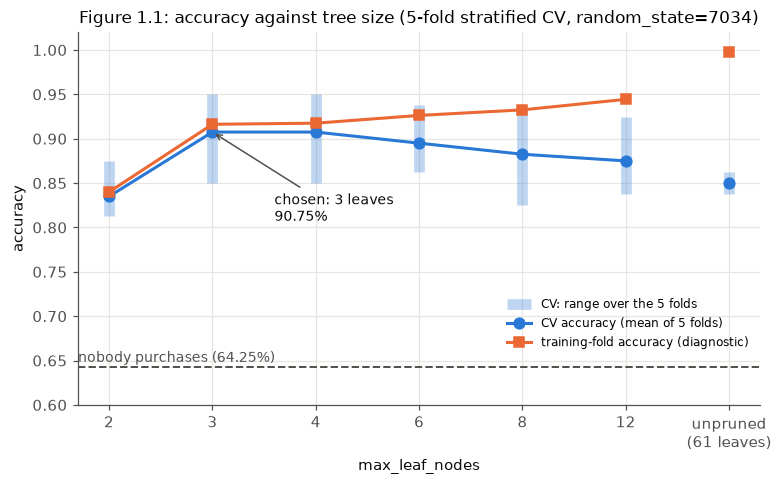

In [5]:
# Figure 1.1: CV accuracy against tree size, with the training-fold accuracy as the over-fitting diagnostic
order = [f'{k} leaves' for k in sizes] + ['unpruned']
labels = [str(k) for k in sizes] + [f'unpruned\n({full_unpruned.get_n_leaves()} leaves)']
x = np.arange(len(order))
cv_mean = tab11.loc[order, 'CV accuracy'].to_numpy()
lo, hi = tab11.loc[order, 'fold min'].to_numpy(), tab11.loc[order, 'fold max'].to_numpy()
tr = tab11.loc[order, 'training-fold accuracy (diagnostic)'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.vlines(x, lo, hi, color=C_BLUE, alpha=0.3, linewidth=7, label='CV: range over the 5 folds')
ax.plot(x[:-1], cv_mean[:-1], 'o-', color=C_BLUE, markersize=7, label='CV accuracy (mean of 5 folds)')
ax.plot(x[-1:], cv_mean[-1:], 'o', color=C_BLUE, markersize=7)
ax.plot(x[:-1], tr[:-1], 's-', color=C_ORANGE, markersize=6, label='training-fold accuracy (diagnostic)')
ax.plot(x[-1:], tr[-1:], 's', color=C_ORANGE, markersize=6)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.3, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
i = sizes.index(k_star)
ax.annotate(f'chosen: {k_star} leaves\n{cv_mean[i]:.2%}', xy=(x[i], cv_mean[i]), xytext=(x[i] + 0.6, cv_mean[i] - 0.1),
            color=C_INK, fontsize=9, arrowprops=dict(arrowstyle='->', color=C_GREY))
ax.set_xticks(x, labels)
ax.set_xlabel('max_leaf_nodes')
ax.set_ylabel('accuracy')
ax.set_ylim(0.6, 1.02)
ax.set_title('Figure 1.1: accuracy against tree size (5-fold stratified CV, random_state=7034)')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:**

**The bar to beat.** The rule "nobody purchases" is right for every non-buyer: **257 of 400 = 64.25%**. On the individual folds it scores 63.75% to 65.00%, because 257 cannot be split exactly evenly into five stratified folds. Every model below has to beat 64.25% (L6 p.57: accuracy is reported "with the majority-class rate next to it").

**The unpruned tree** scores **85.00%** in 5-fold CV (340/400). That is well above the bar, but it is the worst tree in Table 1.1 except the 2-leaf stump. Grown on all 400 people it has 61 leaves and depth 14. It classifies 399 of the 400 correctly in sample (the one miss is a pair of identical people with opposite outcomes), yet only 85% of people it has not seen. It is memorising noise (L8 p.30, p.38).

**The sweep** (Table 1.1, Figure 1.1):

| `max_leaf_nodes` | 2 | 3 | 4 | 6 | 8 | 12 |
|---|---|---|---|---|---|---|
| CV accuracy | 83.50% | **90.75%** | **90.75%** | 89.50% | 88.25% | 87.50% |

**Cross-validation prefers 3 leaves.** 3 and 4 leaves tie exactly (363/400 correct), and the tie goes to the smaller tree. The tie is not a coincidence: the fourth split only divides a leaf into two leaves with the same predicted class, so the two trees make identical out-of-fold predictions for all 400 people (checked in the cell above). The choice matches Lecture 8's own tree for this dataset (L8 p.33).

**Either side of the optimum:**
- **Fewer leaves: underfitting (bias).** With 2 leaves the tree makes a single split, the Age split at the root in 1.2. It scores 83.50% in CV and 84.0% on its own training folds. Training and test accuracy are both low, so the model is too simple: it misses that younger people with high salaries buy.
- **More leaves: overfitting (variance).** From 6 to 12 leaves, CV accuracy falls from 89.50% to 87.50% while training-fold accuracy keeps rising, from 92.6% to 94.4%. The fully grown tree takes this to the extreme: 99.8% on the training folds and 85.00% out of sample. This is the hump shape of L8 p.32.

**How much to read into the gaps.** One person is 1.25 percentage points of a fold and 0.25 pp of the pooled figure. The 3-leaf tree's fold scores range from 85.0% to 95.0%, so neighbouring sizes (3 vs 6 leaves: 5 people out of 400) are within fold-to-fold noise. The 90.75% also won a search over six sizes, so it is slightly optimistic as an estimate of future accuracy (L4 p.43; L5 p.57). The preference for a small tree does not depend on this: 2 to 4 leaves carry the signal, and larger trees only add noise.

**1.2.** Plot the tree you chose in 1.1 (`plot_tree` with `feature_names=Xa.columns`), and then **say what it does in one or two English sentences** — the kind you could put in front of someone with no statistics.

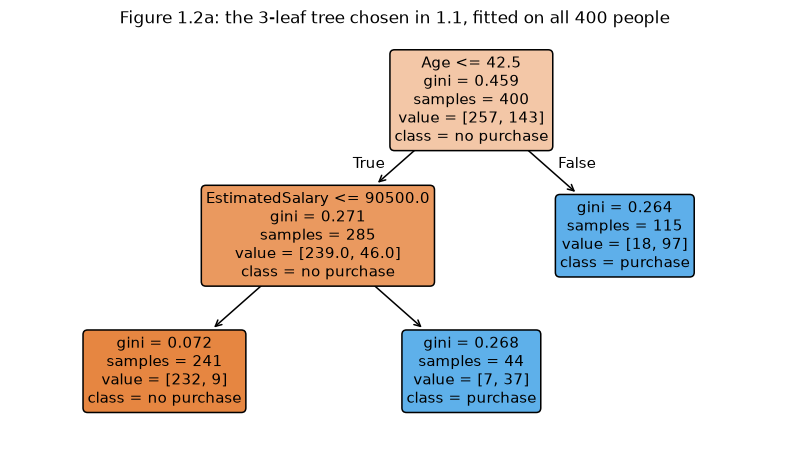

|--- Age <= 42.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- weights: [232.00, 9.00] class: 0
|   |--- EstimatedSalary >  90500.00
|   |   |--- weights: [7.00, 37.00] class: 1
|--- Age >  42.50
|   |--- weights: [18.00, 97.00] class: 1

in-sample accuracy of this tree: 91.50% (diagnostic; its honest accuracy is the CV figure)


,rule,people,buyers,purchase rate,tree predicts
leaf,,,,,
2,Age > 42.5,115,97,84%,purchase
3,Age <= 42.5 and EstimatedSalary <= 90500,241,9,4%,no purchase
4,Age <= 42.5 and EstimatedSalary > 90500,44,37,84%,purchase


Does the tree use Gender? False


In [6]:
# Refit the size CV chose on all 400 people: CV chose a size, not a particular tree (L5 p.36; L8 p.33).
tree_star = DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034).fit(Xa, ya)

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_tree(tree_star, feature_names=Xa.columns, class_names=['no purchase', 'purchase'],
          filled=True, rounded=True, impurity=True, fontsize=10, ax=ax)
ax.set_title(f'Figure 1.2a: the {k_star}-leaf tree chosen in 1.1, fitted on all {N} people')
plt.show()
print(export_text(tree_star, feature_names=list(Xa.columns), show_weights=True))
print(f'in-sample accuracy of this tree: {tree_star.score(Xa, ya):.2%} (diagnostic; its honest accuracy is the CV figure)')

def leaf_rules(tree, names):
    """The conditions that lead to each leaf, in words."""
    t, rules = tree.tree_, {}
    def walk(node, conds):
        if t.children_left[node] == -1:
            rules[node] = ' and '.join(conds) if conds else 'everyone'
            return
        f, thr = names[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], conds + [f'{f} <= {thr:g}'])
        walk(t.children_right[node], conds + [f'{f} > {thr:g}'])
    walk(0, [])
    return rules

rules = leaf_rules(tree_star, list(Xa.columns))
tab12 = (pd.DataFrame({'leaf': tree_star.apply(Xa), 'bought': ya}).groupby('leaf')['bought']
           .agg(people='size', buyers='sum'))
tab12['purchase rate'] = tab12.buyers / tab12.people
tab12['tree predicts'] = np.where(tab12['purchase rate'] > 0.5, 'purchase', 'no purchase')
tab12.insert(0, 'rule', [rules[i] for i in tab12.index])
display(tab12.style.format({'purchase rate': '{:.0%}'}).set_caption('Table 1.2: the leaves of the chosen tree'))
uses_gender = 0 in set(tree_star.tree_.feature[tree_star.tree_.feature >= 0])
print('Does the tree use Gender?', uses_gender)

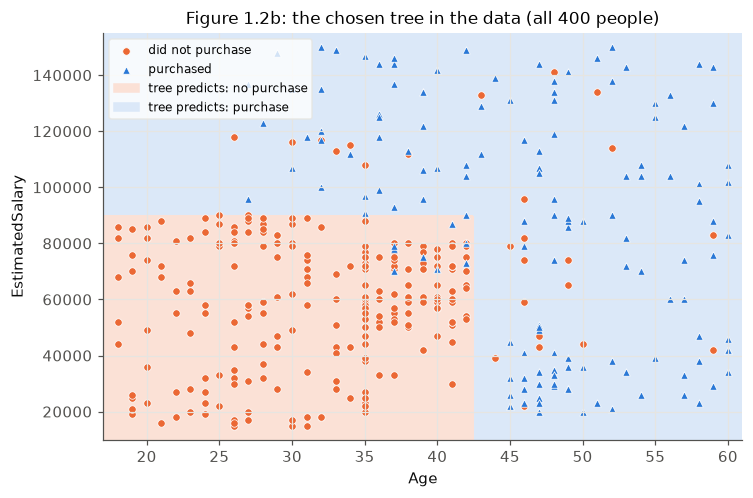

fold 1 tree splits: Age <= 44.5; EstimatedSalary <= 91500
fold 2 tree splits: Age <= 44.5; EstimatedSalary <= 89500
fold 3 tree splits: Age <= 42.5; EstimatedSalary <= 89500
fold 4 tree splits: Age <= 42.5; EstimatedSalary <= 90500
fold 5 tree splits: Age <= 42.5; EstimatedSalary <= 90500


In [7]:
# Figure 1.2b: where the tree predicts "purchase" in the Age x Salary plane (as in L8 p.34)
from matplotlib.patches import Patch
AA, SS = np.meshgrid(np.linspace(17, 61, 300), np.linspace(10_000, 155_000, 300))
genders = [0, 1] if uses_gender else [0]           # Gender only needs its own panel if the tree uses it
fig, axes = plt.subplots(1, len(genders), figsize=(7.5 * len(genders), 4.8), squeeze=False)
for ax, g in zip(axes[0], genders):
    grid = pd.DataFrame({'Gender': g, 'Age': AA.ravel(), 'EstimatedSalary': SS.ravel()})[Xa.columns]
    Z = tree_star.predict(grid).reshape(AA.shape)
    ax.contourf(AA, SS, Z, levels=[-0.5, 0.5, 1.5], colors=['#fbe1d6', '#dbe8f8'])   # same colours as plot_tree
    pts = ads if not uses_gender else ads[ads.Gender == g]
    for val, col, mk, lab in [(0, C_ORANGE, 'o', 'did not purchase'), (1, C_BLUE, '^', 'purchased')]:
        s = pts[pts.Purchased == val]
        ax.scatter(s.Age, s.EstimatedSalary, s=24, c=col, marker=mk, edgecolors='white', linewidths=0.5, label=lab)
    handles = ax.get_legend_handles_labels()[0] + [Patch(color='#fbe1d6', label='tree predicts: no purchase'),
                                                  Patch(color='#dbe8f8', label='tree predicts: purchase')]
    ax.legend(handles=handles, loc='upper left', fontsize=8, frameon=True, facecolor='white', edgecolor=C_LIGHT)
    ax.set_xlabel('Age')
    ax.set_ylabel('EstimatedSalary')
    ax.set_title('Figure 1.2b: the chosen tree in the data' + (f' (Gender = {g})' if uses_gender else ' (all 400 people)'))
plt.show()

# How stable is the structure? The same size fitted on each CV training fold (320 people each; L8 p.40).
folds_fit = cross_validate(DecisionTreeClassifier(max_leaf_nodes=k_star, random_state=7034), Xa, ya,
                           cv=cv5, return_estimator=True)['estimator']
for i, est in enumerate(folds_fit, 1):
    t = est.tree_
    print(f'fold {i} tree splits:', '; '.join(f'{Xa.columns[t.feature[n]]} <= {t.threshold[n]:g}'
                                              for n in range(t.node_count) if t.feature[n] >= 0))

**Answer:**

People over 42 mostly bought (97 of 115, about 84 in every 100), and so did people aged 42 or younger earning more than $90,000 (37 of 44, again about 84 in 100), while younger people earning $90,000 or less almost never bought (9 of 241, about 4 in 100). Gender plays no part in the rule.

*Technical note (outside the two sentences).*
- The tree is refit on all 400 people at the size chosen in 1.1, because cross-validation chooses a size, not a particular tree (L5 p.36, as in L8 p.33).
- Its honest accuracy is the 5-fold figure from 1.1, 90.75%, not the 91.5% it scores on the people it was fitted to.
- It is the same tree as L8 p.33, split by split.
- It is stable: the five trees fitted on the CV training folds all split on Age and then Salary, with age thresholds between 42.5 and 44.5 and salary thresholds between $89,500 and $91,500.

**1.3.** Fit a random forest (300 trees) and a gradient boosted model (100 rounds), both with `random_state=7034`, and report their 5-fold accuracies.

Do they beat the tree from 1.1? Report what you find **whichever way it comes out**, and explain in two or three sentences why that might be, given the size and shape of this dataset.

In [8]:
rf = RandomForestClassifier(n_estimators=300, random_state=7034)
gb = GradientBoostingClassifier(n_estimators=100, random_state=7034)
tab13 = pd.concat([tab11.loc[['unpruned', f'{k_star} leaves']],
                   pd.DataFrame([cv_detail(rf, 'random forest (300 trees)'),
                                 cv_detail(gb, 'gradient boosting (100 rounds)')]).set_index('model')])

# Head to head with the chosen tree on the same 5 folds (people correct per fold of 80)
tree_folds = tab11.loc[f'{k_star} leaves', 'folds']
tab13['vs chosen tree (people /400)'] = tab13['correct /400'] - tab11.loc[f'{k_star} leaves', 'correct /400']
tab13['folds better / equal / worse than tree'] = [
    f'{(f > tree_folds).sum()} / {(f == tree_folds).sum()} / {(f < tree_folds).sum()}' for f in tab13['folds']]
tab13['people correct per fold (of 80)'] = [' '.join(map(str, f)) for f in tab13['folds']]
pct = ['CV accuracy', 'fold min', 'fold max', 'training-fold accuracy (diagnostic)']
display(tab13.drop(columns='folds').style.format({**{c: '{:.2%}' for c in pct}, 'fold sd': '{:.3f}'})
        .set_caption(f'Table 1.3: ensembles against the {k_star}-leaf tree (same 5 folds; baseline {base_correct / N:.2%})'))

# The settings actually used (the exam fixes 300 trees / 100 rounds; everything else is the sklearn default)
rf_full = RandomForestClassifier(n_estimators=300, random_state=7034).fit(Xa, ya)
print('RF:', {k: rf.get_params()[k] for k in ['n_estimators', 'max_features', 'max_depth', 'min_samples_leaf', 'bootstrap']},
      '| features tried at each split:', rf_full.estimators_[0].max_features_,
      '| mean leaves per tree:', round(np.mean([t.get_n_leaves() for t in rf_full.estimators_]), 1))
print('GB:', {k: gb.get_params()[k] for k in ['n_estimators', 'learning_rate', 'max_depth', 'subsample']})

,CV accuracy,correct /400,fold min,fold max,fold sd,training-fold accuracy (diagnostic),vs chosen tree (people /400),folds better / equal / worse than tree,people correct per fold (of 80)
model,,,,,,,,,
unpruned,85.00%,340,83.75%,86.25%,0.013,99.81%,-23,0 / 0 / 5,67 68 69 67 69
3 leaves,90.75%,363,85.00%,95.00%,0.037,91.63%,0,0 / 5 / 0,68 72 73 74 76
random forest (300 trees),88.75%,355,85.00%,92.50%,0.032,99.81%,-8,2 / 0 / 3,69 73 71 68 74
gradient boosting (100 rounds),89.00%,356,83.75%,93.75%,0.040,97.44%,-7,1 / 2 / 2,69 72 73 67 75


RF: {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True} | features tried at each split: 1 | mean leaves per tree: 50.2
GB: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}


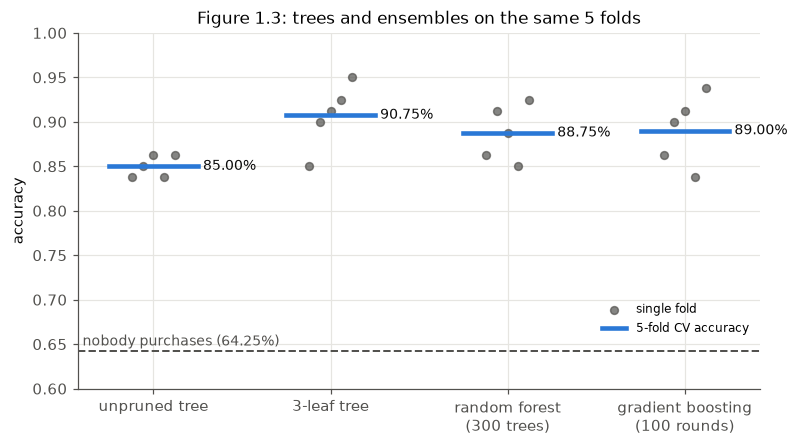

In [9]:
# Figure 1.3: the five fold scores and their mean for each model, against the baseline
models = ['unpruned', f'{k_star} leaves', 'random forest (300 trees)', 'gradient boosting (100 rounds)']
fig, ax = plt.subplots(figsize=(8, 4.2))
for j, m in enumerate(models):
    f = tab13.loc[m, 'folds'] / 80
    ax.scatter(np.full(5, j) + np.linspace(-0.12, 0.12, 5), f, s=26, color=C_GREY, alpha=0.7,
               label='single fold' if j == 0 else None, zorder=2)
    ax.plot([j - 0.25, j + 0.25], [tab13.loc[m, 'CV accuracy']] * 2, color=C_BLUE, linewidth=3,
            label='5-fold CV accuracy' if j == 0 else None, zorder=3)
    ax.text(j + 0.28, tab13.loc[m, 'CV accuracy'], f"{tab13.loc[m, 'CV accuracy']:.2%}", va='center', fontsize=9, color=C_INK)
ax.axhline(base_correct / N, color=C_GREY, linestyle='--', linewidth=1.3)
ax.text(-0.4, base_correct / N + 0.006, f'nobody purchases ({base_correct / N:.2%})', color=C_GREY, fontsize=9)
ax.set_xticks(range(len(models)), ['unpruned tree', f'{k_star}-leaf tree', 'random forest\n(300 trees)',
                                   'gradient boosting\n(100 rounds)'])
ax.set_ylabel('accuracy')
ax.set_ylim(0.6, 1.0)
ax.set_title('Figure 1.3: trees and ensembles on the same 5 folds')
ax.legend(loc='lower right', bbox_to_anchor=(1, 0.12), fontsize=8)
plt.show()

**Answer:**

**Results (Table 1.3, Figure 1.3, same five folds as 1.1):**

| model | 5-fold CV accuracy | people correct /400 |
|---|---|---|
| nobody purchases | 64.25% | 257 |
| unpruned tree | 85.00% | 340 |
| **3-leaf tree (from 1.1)** | **90.75%** | **363** |
| random forest, 300 trees | 88.75% | 355 |
| gradient boosting, 100 rounds | 89.00% | 356 |

**Neither ensemble beats the 3-leaf tree.** Both are far above the 64.25% bar and above the unpruned tree, but they get 8 (forest) and 7 (boosting) fewer people right than the 3-leaf tree. Fold by fold the verdict is mixed: the forest beats the tree in 2 folds and loses in 3; boosting beats it in 1, ties in 2 and loses in 2. The fair reading is therefore "no better than the small tree", not "worse", because the gaps are inside the tree's own fold-to-fold range of 85% to 95%.

**Why:** With 400 people and effectively two inputs that matter, the buying pattern is close to one rectangle in the Age × Salary plane (Figure 1.2b), which a 3-leaf tree already draws, so there is little left for an ensemble to fix: a forest averages away *variance* and boosting adds shallow trees to remove *bias* (L8 p.51), and the small tree has little of either. What the ensembles add instead is flexibility to chase noise in 320-person training folds (training-fold accuracy 99.8% for the forest and 97.4% for boosting, against 91.6% for the tree), and both run at untuned settings (the forest tries one of the three features at each split; boosting uses learning rate 0.1, depth 3), so on data this small and this simple the readable tree is the better choice (L8 p.54–55, p.61).

**1.4.** Split the data 70/30 (`random_state=7034`, `stratify=ya`), fit a 300-tree forest on the training set, and compute two importance rankings: `feature_importances_` (mean decrease in impurity, computed **in sample**) and `permutation_importance` on the **held-out** 30%.

Put them side by side. Do the two rankings agree on which variable matters most? Where they disagree, explain why — and say which of the two you would show to someone making a decision.

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(Xa, ya, test_size=0.3, random_state=7034, stratify=ya)
print(f'training: {len(X_tr)} people ({int(y_tr.sum())} buyers); held out: {len(X_te)} people ({int(y_te.sum())} buyers)')
rf14 = RandomForestClassifier(n_estimators=300, random_state=7034).fit(X_tr, y_tr)
print(f'Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy '
      f'{rf14.score(X_tr, y_tr):.3f}, held-out accuracy {rf14.score(X_te, y_te):.3f}, '
      f'held-out "nobody purchases" {(y_te == 0).mean():.3f}; mean leaves per tree '
      f'{np.mean([t.get_n_leaves() for t in rf14.estimators_]):.1f}')

mdi = pd.Series(rf14.feature_importances_, index=Xa.columns)     # mean decrease in impurity, in sample (L8 p.47, p.56)
pi_te = permutation_importance(rf14, X_te, y_te, scoring='accuracy', n_repeats=50, random_state=7034)  # held out (L8 p.57)
pi_tr = permutation_importance(rf14, X_tr, y_tr, scoring='accuracy', n_repeats=50, random_state=7034)  # diagnostic
perm = pd.Series(pi_te.importances_mean, index=Xa.columns)
splits = pd.Series([sum(int((t.tree_.feature == j).sum()) for t in rf14.estimators_) for j in range(Xa.shape[1])],
                   index=Xa.columns)
tab14 = pd.DataFrame({
    'MDI share (in-sample)': mdi,
    'MDI rank': mdi.rank(ascending=False, method='min').astype(int),
    'held-out accuracy drop (pp)': 100 * perm,
    'sd over 50 shuffles (pp)': 100 * pd.Series(pi_te.importances_std, index=Xa.columns),
    'permutation share': perm.clip(lower=0) / perm.clip(lower=0).sum(),   # negative drops set to 0 before normalising
    'permutation rank': perm.rank(ascending=False, method='min').astype(int),
    'diagnostic: drop on training rows (pp)': 100 * pd.Series(pi_tr.importances_mean, index=Xa.columns),
    'splits in the forest': splits,
    'distinct values': Xa.nunique()}).sort_values('permutation rank')
assert np.isclose(mdi.sum(), 1) and pi_te.importances.shape == (3, 50)
display(tab14.style.format({'MDI share (in-sample)': '{:.3f}', 'permutation share': '{:.3f}',
                            'held-out accuracy drop (pp)': '{:.2f}', 'sd over 50 shuffles (pp)': '{:.2f}',
                            'diagnostic: drop on training rows (pp)': '{:.2f}'})
        .set_caption('Table 1.4: two importance rankings for the same 300-tree forest'))
print(f'corr(Age, EstimatedSalary) = {Xa.Age.corr(Xa.EstimatedSalary):.3f}')

training: 280 people (100 buyers); held out: 120 people (43 buyers)


Diagnostics only (the reported RF accuracy is the 5-fold figure in 1.3): training accuracy 0.996, held-out accuracy 0.917, held-out "nobody purchases" 0.642; mean leaves per tree 38.2


,MDI share (in-sample),MDI rank,held-out accuracy drop (pp),sd over 50 shuffles (pp),permutation share,permutation rank,diagnostic: drop on training rows (pp),splits in the forest,distinct values
Age,0.470,2,25.50,3.66,0.569,1,26.96,4751,43
EstimatedSalary,0.519,1,17.13,2.95,0.382,2,28.83,5623,117
Gender,0.011,3,2.18,1.21,0.049,3,5.03,776,2


corr(Age, EstimatedSalary) = 0.155


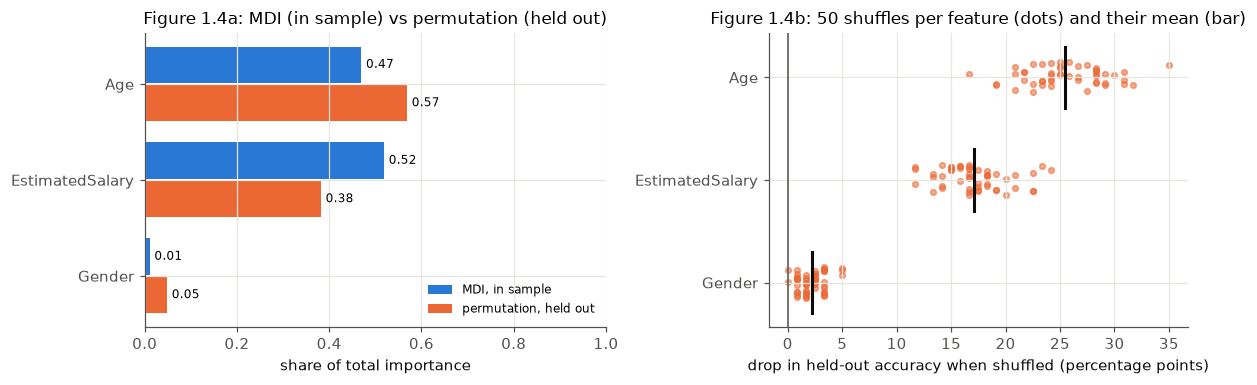

In [11]:
# Figure 1.4: the two rankings side by side (left) and the spread of the 50 held-out shuffles (right)
feats = list(tab14.index)[::-1]                      # most important (by permutation) at the top
yy = np.arange(len(feats))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'width_ratios': [1.1, 1]})
ax1.barh(yy + 0.2, tab14.loc[feats, 'MDI share (in-sample)'], height=0.38, color=C_BLUE, label='MDI, in sample')
ax1.barh(yy - 0.2, tab14.loc[feats, 'permutation share'], height=0.38, color=C_ORANGE, label='permutation, held out')
for k, f in enumerate(feats):
    ax1.text(tab14.loc[f, 'MDI share (in-sample)'] + 0.01, k + 0.2, f"{tab14.loc[f, 'MDI share (in-sample)']:.2f}", va='center', fontsize=8)
    ax1.text(tab14.loc[f, 'permutation share'] + 0.01, k - 0.2, f"{tab14.loc[f, 'permutation share']:.2f}", va='center', fontsize=8)
ax1.set_yticks(yy, feats)
ax1.set_xlabel('share of total importance')
ax1.set_xlim(0, 1)
ax1.legend(loc='lower right', fontsize=8)
ax1.set_title('Figure 1.4a: MDI (in sample) vs permutation (held out)')
rng_jit = np.random.default_rng(7034)                  # vertical jitter only, so the dots do not sit on top of each other
for k, f in enumerate(feats):
    drops = 100 * pi_te.importances[list(Xa.columns).index(f)]
    ax2.scatter(drops, k + rng_jit.uniform(-0.15, 0.15, drops.size), s=14, color=C_ORANGE, alpha=0.55)
    ax2.plot([drops.mean()] * 2, [k - 0.3, k + 0.3], color=C_INK, linewidth=2)
ax2.set_yticks(yy, feats)
ax2.axvline(0, color=C_GREY, linewidth=1)
ax2.set_xlabel('drop in held-out accuracy when shuffled (percentage points)')
ax2.set_title('Figure 1.4b: 50 shuffles per feature (dots) and their mean (bar)')
plt.tight_layout()
plt.show()

**Answer:**

**Setup.** The data are split 70/30, stratified, with `random_state=7034`: 280 people for training (100 buyers) and 120 held out (43 buyers). The forest has 300 trees. Its held-out accuracy of 91.7% is shown only as a diagnostic; the forest's reported accuracy is the 5-fold 88.75% from 1.3.

**Side by side (Table 1.4, Figure 1.4):**

| feature | MDI share, in sample | MDI rank | held-out permutation: accuracy drop (sd over 50 shuffles) | permutation rank |
|---|---|---|---|---|
| Age | 0.470 | 2 | **25.5 pp** (3.7) | **1** |
| EstimatedSalary | **0.519** | **1** | 17.1 pp (3.0) | 2 |
| Gender | 0.011 | 3 | 2.2 pp (1.2) | 3 |

**Do they agree on the most important variable? No.** MDI puts Salary first; held-out permutation puts Age first. They agree that Gender matters least.

**Why they disagree:**
- **MDI is computed in sample** (L8 p.47, p.56). It adds up the impurity reduction of every split the forest makes on its own training rows. These trees are grown deep (about 38 leaves each, 99.6% training accuracy), so many splits fit noise, and each of those splits is credited to some variable.
- **Salary offers the most places to split.** It has 117 distinct values against 43 for Age and 2 for Gender, so the forest splits on it 5,623 times against 4,751 for Age. The noise-fitting splits pile up credit for Salary. L8 p.58 describes exactly this: MDI "rewards a column for merely offering many places to split".
- **The diagnostic column confirms the mechanism.** Permutation importance computed on the *training* rows also ranks Salary above Age (28.8 vs 27.0 pp). On people it has memorised, the forest leans on Salary. On people it has not seen, removing Age costs more.
- **Shared credit between correlated inputs** is L8 p.58's other mechanism, but it is not the main story here: Age and Salary are only weakly correlated (0.155).

**What I would show a decision maker: the held-out permutation ranking.** It measures how much accuracy on new people is lost when a variable's information is destroyed, which is the question the decision maker is actually asking (L8 p.57: it "answers the question you actually asked"). Three caveats come with it:
- It rests on 120 people. The shuffles alone move it by ±3 to 4 pp, and a different split would move it more.
- Importance has no sign (L8 p.60). The direction comes from 1.2: older people, and younger people with high salaries, are the likely buyers.
- It describes what the model uses, not a causal effect.

**1.5** (Open-Ended) Each row here is a *person*, and the rows are unrelated to each other. Suppose instead each row were a *month* of one stock's data, and you were predicting whether next month's return is positive.

Cross-validation with `shuffle=True` — which you used throughout this problem — would then be **wrong**. Explain precisely what goes wrong, what you would do instead, and which way the error would push your reported accuracy.

In [12]:
# No code is needed for 1.5: the answer below is conceptual (the exam asks for code only "if any").

**Answer:**

**What goes wrong.** Shuffled K-fold assumes the rows are exchangeable draws, like unrelated people (L5 p.28; L8 p.45). Months of one stock are not.
1. **The future leaks into training (look-ahead).** `StratifiedKFold(shuffle=True)` assigns months to folds at random. So the model that is scored on, say, 2015 has been trained on 2016–2021, information no forecaster ever has. "The random fold sees the future" (L5 p.56); "watch whether the future ends up in the training set. It usually does" (L1 p.82).
2. **Neighbouring months are near-duplicates.** Predictors built from trailing windows barely change from one month to the next (a 12-month past return shares 11 of its 12 months with the next row's), and calm and turbulent periods persist. Each test month therefore has its almost identical neighbours in the training folds, and a tree can look up their answers rather than forecast. This mechanism is our own reasoning; the course's rule is simply that "the order of data is respected" (L5 p.27) and that "CV is not valid with time-series data" (L5 p.48).
3. **The model is then tuned to the leak.** Validation looks too good for complex settings, so CV picks too big a tree. In the lecture's own experiment, random folds on time-ordered data under-regularised (23 variables instead of 15) and cost 0.036 of out-of-sample R² (L5 p.56).
4. **Two tempting fixes do not help.**
   - Dropping `shuffle` alone does not fix it: `KFold(shuffle=False)` still trains the early folds on later data.
   - Stratifying makes it slightly worse: it builds every fold with the full-period share of up months, which is itself only known at the end.

**Which way the error goes.** The reported accuracy is **biased upward**, i.e. too optimistic in expectation: every leak adds information a real forecaster would not have. The course grades this as a fatal error (L5 p.58, item 3; AI guide §4a). Monthly return signs carry little signal (L1 p.33), so an honest accuracy close to the "always up" base rate is normal. A much higher number is a prompt "to go looking for the leak" (L5 p.57).

**What to do instead: time-ordered, walk-forward evaluation** (L5 p.48–52; L6 p.30, "as it would be if the model were put to use").
- **Build predictors from information known by the end of month t−1** and lag them. Fit any scaler or imputer inside each training window only.
- **Use an expanding window.** Train on months 1…t. Choose `max_leaf_nodes` on the *following* validation block. Predict the next test block. Roll forward and pool the test predictions (a rolling window of fixed length is the alternative if the stock's behaviour drifts).
- **Keep a final test period untouched** until the model is chosen, and touch it once (L4 p.43; L8 p.55).
- **Report the accuracy next to a benchmark fixed in advance:** the majority direction ("always up") learned from the training months only, never from the test period (L6 p.57; L4 p.46).

---
# Problem 2: Training on Your Own Output (20 points)

A risk desk estimates the daily volatility of its portfolio from a library of past daily returns
and reports the one-day 1% Value-at-Risk. Under a fitted normal distribution $N(0, \hat\sigma^2)$
the 1% quantile is $-2.326\,\hat\sigma$, so the desk reports $\text{VaR} = 2.326\,\hat\sigma$: under
this model, estimating VaR *is* estimating $\hat\sigma$. In 2016 the desk decided that the library
should be refreshed every night so that it always reflects the newest model. Its pipeline manual:

> *Every night the pipeline **(1)** fits $\hat\sigma^2$ to the library with the usual unbiased sample
> variance, $\hat\sigma^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar x)^2$, and sets the mean of the
> fitted normal to zero; **(2)** draws 500 fresh scenarios from $N(0, \hat\sigma^2)$; **(3)** replaces
> the library with tonight's 500 scenarios, so the library keeps its size, because the newest model is the best model and
> yesterday's data came from a worse one; and **(4)** reports $\text{VaR} = 2.326\,\hat\sigma$.*

On the first night the library held 500 real daily returns. The pipeline then ran every night for
ten years, 2,500 refits in all, and the reported VaR fell from 2.8% of NAV to 0.24%, while the
volatility of the desk's markets had not changed. The desk was praised for de-risking. The Chief Risk Officer, who does not
believe in free lunches, wants to know what happened.

**Rules.** Work in units of the true volatility: $\sigma = 1$, so the *correct* VaR is $2.326$ on
every night and nothing about the market changes. Set `SEED` to the last four digits of your student ID; your numbers will differ from your classmates', and that is the point. A "desk" is one run of the
pipeline; every desk starts on night 1 from a library whose sample variance is exactly 1, and when a
part needs the real days themselves, take them to be 500 draws from $N(0, 1)$. Every number you
report must come from a cell in this notebook.


In [ ]:
from scipy.stats import norm, kurtosis
import time

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'

SEED   = 0             # <-- the last four digits of your student ID
N_SCEN = 500           # scenarios drawn per night
NIGHTS = 2500          # ten trading years
Z01    = norm.ppf(0.99)   # 2.326: the 1% one-day VaR of N(0, 1), in units of sigma
print(f"correct VaR, every night, in units of sigma: {Z01:.3f}")


**2.1.** (2 points) **Commit before you compute.** Answer in the markdown cell below *before*
writing any code. The estimator in step (1) is unbiased, so each night's estimate is, on average,
equal to the previous night's. Does that mean the reported VaR should stay near 2.326 for ten
years? Say what you expect to see on night 2,500 and why, in two or three sentences. No marks depend
on being right; **2.3** asks you to reconcile your answer with what you find.


**Answer:** 


**2.2.** (6 points) **One desk, then a thousand.** Simulate one desk for 2,500 nights exactly as
the manual describes: fit $\hat\sigma^2$ with `var(ddof=1)`, draw 500 scenarios from
$N(0, \hat\sigma^2)$, replace the library. Plot $\log\hat\sigma^2$ against the night and report
$\hat\sigma^2$ and the reported VaR on night 2,500.

Then run a thousand desks (a loop over nights that draws a $1000 \times 500$ matrix each night takes
seconds). For night 2,500 report the mean, median, 5th and 95th percentiles and maximum of
$\hat\sigma^2$, and the fraction of desks reporting a VaR below one-tenth of the truth. Where does
your one desk sit in that distribution? Is the story's fall from 2.8% to 0.24% typical?


In [ ]:
# Your codes here.


**Answer:** 


**2.3.** (6 points) **Unbiased every night, wrong in the end.** Verify in a cell that
$E[\hat\sigma^2_{t+1} \mid \hat\sigma^2_t] = \hat\sigma^2_t$: start many desks at the same
$\hat\sigma^2_t$, take one step of the pipeline, and average. So the mathematically expected value
of $\hat\sigma^2$ on night 2,500 is exactly 1. Then measure the *average nightly change in
$\log\hat\sigma^2$* for $n = 50$, $500$ and $5{,}000$ scenarios per night (a few hundred desks and a
few hundred nights are enough) and propose the formula relating it to $n$; it is simple. Plot the
histogram of $\log\hat\sigma^2$ across your thousand desks on night 2,500.

In one paragraph, reconcile three numbers that are all correct: the expectation is exactly 1, your
median is far below 1, and your thousand-desk mean is neither (what share of the sum of your
thousand estimates is held by the ten largest?). Why does "unbiased at every step" not protect a
pipeline that trains on its own output?


In [ ]:
# Your codes here.


**Answer:** 


**2.4.** (6 points) **What synthetic data can and cannot carry.** Two experiments.

(a) Keep the 500 real days in the library permanently, and add each night's 500 scenarios to them
instead of replacing them, so the library holds 1,000 returns, half real and half synthetic. Report the median and the 5th and 95th percentiles of $\hat\sigma^2$ on
night 2,500 across a thousand desks.

(b) Seed the library with real returns instead. `dj30.csv` is a daily panel of Dow stocks, one row
per stock per date, and the daily market return `MrkRet` is repeated on every row for that date;
reduce it to one value per date (for example `dj.groupby('date').MrkRet.first()`), which gives 1,511
trading days for 2016–2021 including March 2020. Report the sample volatility and the excess
kurtosis of the real returns. Then compare two things *on night 1, before the pipeline has drawn a
single scenario from its own output*: the empirical 1% VaR (the first percentile of the real
returns, sign flipped) against the VaR the pipeline reports, and the excess kurtosis of the real
returns against that of the 500 night-1 scenarios.

Then answer in one paragraph. What does a synthetic sample contain that the real sample did not,
and what does it lack? Which of the two experiments shows a *loss of information* and which shows
an *accumulation of noise*? What does this imply for any pipeline, a risk model, a return forecast
or a language model, that is retrained on data produced by its own previous version, and what is the
only thing that stops it?


In [ ]:
# Your codes here.


**Answer:** 


---
# Problem 3: Research Project — Cross-country asset return prediction (60 points)

This is an open-ended research project rather than a problem set. You are given a research panel of monthly asset returns across several countries and asset classes, with asset-level characteristics and macroeconomic data, and a question. How you answer it — which features you build, which models you fit, how you evaluate them — is your design, and the write-up must defend it. There is no answer key. A negative result, honestly established, earns full credit; an unexplained positive one does not.

**The question.** The empirical asset-pricing literature finds that a small set of asset-level characteristics — variables that describe each asset's own recent behaviour, pricing and risk, and that differ across assets at a point in time — predict returns across many markets and asset classes, and systematic funds trade on exactly these cross-sectional signals. The panel you are given carries five such characteristics per asset, with their names hidden, together with global and country-level macro variables. What a desk that trades across countries and asset classes wants to know is:

1. How much of next month's excess return is forecastable from lagged characteristics?
2. Does macroeconomic information — global or country-level — add anything to the characteristics?
3. Does a forecast-based portfolio beat the simple rules (equal weight, risk parity, time-series momentum) out of sample, after costs?

Any method is allowed: OLS, ridge, lasso, PCR, KNN, trees, random forests, boosting, neural networks, or anything else you want to try; static, expanding-window or rolling-window estimation; cross-validation or information criteria for tuning. The choice is yours; the discipline of the evaluation is what is graded.


## Data

All files are in `_DATA_DIR`. Dates are month-ends, January 2000 to December 2024. Returns are monthly **excess** returns in decimals. Asset, asset-class, country and variable names are anonymized.

| file | grain | columns |
|---|---|---|
| `asset_panel.csv` | asset × month (50 × 300) | `date, asset_id, asset_class, country, excess_return, x1 ... x5` |
| `asset_returns_wide.csv` | month × asset | the same returns, one column per asset |
| `asset_info.csv` | asset | `asset_class` (A, B, C, D) and `country` of each asset |
| `macro_global.csv` | month | `x6 ... x9`, global variables |
| `macro_country.csv` | country × month, 12 countries | `x10 ... x16`, curated country-level variables |
| `macro_country_extended.csv` | country × month, 12 countries | `x17 ... x164`, a wide, uncurated set of further country-level variables that overlaps the curated file (a few of its columns duplicate curated series exactly; find them before you concatenate the two files). Treat as exploratory material of uneven quality |

**Universe.** 50 assets in four asset classes — A (26 assets), B (8), C (9) and D (7) — across 12 countries. Assets in classes B, C and D each belong to one country. **Assets in class A have no natural country**; in the files they are assigned `country_7` by convention (a country that also has one class-C and one class-D asset). If you use country-level macro for class A, the convention gives them country 7's variables, which is one defensible choice among several (see step 2 of the workflow); in a widened-panel design you can give them whatever cross-country information you find sensible.

**Variables.** `x1` to `x5` are cross-sectional asset characteristics: each is computed for every asset every month from that asset's own prices and fundamentals, so at any date it varies across assets and can be used to rank them (one of the five is a risk measure). `x6` to `x164` are macroeconomic and financial-condition variables: rates, inflation, activity, external balances, credit, valuation, uncertainty and risk ratings, and some pre-computed transforms of them. Working out what a variable does — from its persistence, its scale, its cross-sectional behaviour and its relation to returns — is part of the project.

**Read this before modelling.**
- **Lag conventions.** `x2` and `x5` are *already* lagged one month: use them as they are to predict `excess_return` in the same row. `x1`, `x3`, `x4` and **every macro variable** are stored *contemporaneously*: shift them by one month within asset (or country) before using them as predictors. Getting this wrong silently introduces look-ahead. Macro data is also released with a delay; a one-month lag is the minimum, and you may argue for more.
- **Missing values.** The asset panel and the global file have no gaps, but a few leading months of `x2`, `x3` and `x5` in 2000–2002 were filled with the first observed value for a handful of assets; returns were never filled. In the curated country file, `x11` stops being updated before the end of the sample for three countries. In the extended file, seven columns have gaps. If you want to use a series with gaps, you have to deal with them yourself (see step 2 of the workflow).
- **You are free to bring in more data.** If you think other macro series, other asset characteristics, or other information would help the prediction, find it, document its source and its release timing, and treat it as part of your feature engineering. Anything you add is subject to the same lag rules as the data we provide.
- **Scales differ enormously by class.** Monthly return volatility ranges from under 1% to above 17% across assets, and its typical level differs systematically across the four classes. Think about this before pooling assets in one regression or one equal-weighted portfolio.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
# _DATA_DIR = './'    # if the data files sit next to this notebook

panel = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info  = pd.read_csv(_DATA_DIR + 'asset_info.csv', index_col=0)
mac_g = pd.read_csv(_DATA_DIR + 'macro_global.csv', parse_dates=['date'])
mac_c = pd.read_csv(_DATA_DIR + 'macro_country.csv', parse_dates=['date'])
mac_x = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv', parse_dates=['date'])
print(panel.shape, panel.date.min().date(), panel.date.max().date())
panel.head()


## Two rules that apply throughout

1. **Benchmarks before models.** Before you fit anything, write down the simple rules your model must beat and compute their out-of-sample performance. For return forecasts the benchmark is the trailing mean (or zero). For portfolios it is equal weight, risk parity ($w_i \propto 1/\hat\sigma_i$, with $\hat\sigma_i$ a trailing volatility computed from past returns) and time-series momentum ($w_i \propto \mathrm{sign}(\text{trailing 12-month return}_i)/\hat\sigma_i$), all with unit gross exposure and monthly rebalancing. All three can be built from `excess_return` alone.
2. **Time-ordered evaluation.** Fix the out-of-sample window and the initial training block in advance, before you fit anything, and say why you chose them. Every predictor must be known at the end of month $t-1$; every scaler, penalty and hyper-parameter is chosen on training data only; the trailing-mean benchmark for month $t$ is the mean of returns through month $t-1$ only, updated each month (the expanding-window harness of HW5 Problem 1.1, where the $R^2$ benchmark is the mean of the data seen so far).


## A suggested workflow

You do not have to follow this order, but a complete project touches each step.

**1. Know your data.** Cumulative excess returns by asset class; a table of annualized mean, volatility, Sharpe ratio and worst month per asset; the correlation matrix ordered by class (how strong is the block structure, and what does it imply for pooling?); rolling 12-month Sharpe by class (how persistent is performance?); the distribution, scale and persistence of each characteristic within each class, and a first look at its predictive content (average next-month return of assets sorted into terciles on it each month). Form a hypothesis about what each of `x1` to `x5` measures; you will need it to interpret your results.

**2. Feature engineering.** This is where most of the design lives.
- Apply the lag rule. Standardize characteristics cross-sectionally within month (across all assets or within class; z-score or rank) and say why.
- **If you use a macro series with missing values, deal with them first and write down what you did.** Diagnose the pattern for each series and country: does it stop early, or have holes in the middle? Then choose a treatment and justify that it uses *only information available at the time*. Forward-filling the last observed value and dropping the series are legitimate; filling backward, interpolating across a gap, or imputing with a full-sample mean all use the future. One trap worth your attention: a series that stops updating during a regime change, where carrying a stale value forward is not a small error. Check whether the series can be rebuilt, exactly or approximately, from other complete columns in either file, and report how close the rebuild is.
- **Add your own data if you have a hypothesis for it.** More macro series, other characteristics, anything you can source and date properly. Say where it came from, when each value became known, and lag it accordingly.
- Standardize global macro with *trailing* information only (a rolling z-score, for instance), never with the full sample.
- Map country macro to assets through `country`. Classes B, C and D each have their own country, so the mapping is direct; a *differential* against a base country (country 7 is the natural base) is often more informative than a level. Class A has no natural country. The files assign it country 7 by convention, and using country 7's macro for class A is one defensible choice; a cross-country average, cross-country dispersion, or no country macro at all are others. Say which you use and why.
- Consider cross-sectional macro transforms: the rank of a country's value across the 12 countries, its deviation from the cross-country mean, or a widened panel in which each asset sees its own country's macro *and* the cross-country average or every country's value. In the widened panel, class A can be given any cross-country information you find sensible rather than one country's.
- Consider interactions between characteristics and macro states, class dummies, and the extended file if you have a hypothesis for it.
- Choose the target. We recommend the **vol-scaled** excess return $y_{i,t} = r_{i,t}/\hat\sigma_{i,t-1}$ with $\hat\sigma$ a trailing volatility; explain why, and how you turn forecasts back into positions.
- End with one table listing every predictor and the count.

**3. Models and evaluation schemes.** Fit whatever models you find promising — OLS, ridge, lasso, random forests, boosted trees, neural networks, or any other method — and evaluate them under one or more schemes: static (fit once on the initial training block), expanding window (refit periodically on all data to date, the expanding-window scheme of Lecture 5 that you implemented in HW5 Problem 1), rolling window (refit on a fixed-length trailing window). Report $R^2_{OOS}$ against the trailing mean and against zero, model × scheme, and by asset class for the models you care about. Questions worth answering along the way: which scheme wins and why; which predictors carry the signal and whether that is stable across windows; whether macro adds anything once you refit without it; whether a **placebo** (every macro series circularly shifted by 36 months, real data at the wrong time) does about as well as the real macro (a persistent series stays partly correlated with a shifted copy of itself, so try more than one shift); whether per-class models beat the pooled one.

**4. From forecasts to portfolios.** Form portfolios from your forecasts in whatever way you find sensible (positions proportional to the forecast scaled by volatility, the sign of the forecast, long the top and short the bottom of a sort, or your own rule). State clearly how the portfolio is formed and rebalanced, and compare its performance with the benchmarks — Sharpe ratio at a minimum, and whatever else helps the reader judge it (return, volatility, drawdown, turnover, performance net of transaction costs, cumulative-return plots, sub-periods). Where you find outperformance, ask how much of it is exposure to the benchmark rules and how much is timing.


## What to submit

Two things, in this notebook:

1. **The analysis**, running top to bottom on the class server (or with `_DATA_DIR` pointed at a local copy of the data files), with every figure and table the write-up refers to.

2. **A write-up in the form of a research paper**, in markdown at the end of the notebook. The point of this project is to practise doing research, not to answer questions, so write it the way an empirical finance paper is written:

   - **Introduction.** The question, why it matters to someone who allocates money across countries and asset classes, what the literature on cross-sectional return predictability leads you to expect, and a one-paragraph preview of what you find.
   - **Data.** What the panel contains, how you treated it (missing values, lags, standardization, the country-to-asset mapping for macro), summary statistics and the plots that convey the structure of the data.
   - **Methodology.** The benchmarks and why they are the right ones; the models; the evaluation schemes and the out-of-sample window; how penalties and hyper-parameters were chosen; how forecasts become positions; how performance is measured. A reader should be able to reproduce your design from this section alone.
   - **Results.** Tables and figures with the numbers, presented in the order of the questions: forecastability of returns, the contribution of macro, and the portfolio evidence against the benchmarks.
   - **Interpretation and discussion.** What the results mean economically. Why the numbers come out the way they do; where the evidence is strong and where it is fragile; what you tried that did not work; what you would do next with more data or more time.
   - **Conclusion.** A summary a portfolio manager could read on their own.

   There is no length requirement in either direction. Length should follow from what you have to say; a clear negative result written up carefully is a good paper.


In [ ]:
# Your project starts here.


## Write-up

